In [15]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

DATASET_PATH = "/content/drive/MyDrive/ml-semester5/dataset/diabetes_012_health_indicators_BRFSS2015.csv"
OUTPUT_DIR = "output_clustering"
RANDOM_STATE = 42
ELBOW_SAMPLE_SIZE = 30000
SILHOUETTE_SAMPLE_SIZE = 5000
PCA_SAMPLE_SIZE = 10000

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil dimuat.")
print(f"[INFO] Dataset: {DATASET_PATH}")
print(f"[INFO] Folder output: {OUTPUT_DIR}")
print(f"[INFO] Random state: {RANDOM_STATE}")

[INFO] Library berhasil dimuat.
[INFO] Dataset: /content/drive/MyDrive/ml-semester5/dataset/diabetes_012_health_indicators_BRFSS2015.csv
[INFO] Folder output: output_clustering
[INFO] Random state: 42


In [16]:
# =======================================================================
# 2. DATASET & PREPROCESSING
# =======================================================================
from google.colab import drive

drive.mount('/content/drive')

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di: {DATASET_PATH}\n"
        "Pastikan file berada di Google Drive pada folder tersebut."
    )

# Load dataset
df_raw = pd.read_csv(DATASET_PATH)
print(f"[DATA] Dimensi awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

# Preprocessing
# Fokus pada kelas 0 (tidak diabetes) dan 2 (diabetes), sehingga kelas 1 dibuang.
df = df_raw.copy()
n_awal = len(df)

df = df[df['Diabetes_012'] != 1].copy()
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")

# Buang kolom Income seperti pada pengerjaan awal.
if 'Income' in df.columns:
    df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Hapus duplikat.
n_sebelum_dup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

# Pisahkan label asli dari fitur clustering.
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)

print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi untuk Manhattan.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values).astype(np.float64)

# Standardisasi + L2 normalization untuk Cosine / Spherical K-Means.
normalizer = Normalizer(norm='l2')
X_norm = normalizer.fit_transform(X_scaled).astype(np.float64)

print(f"Bentuk data siap klaster : {X_scaled.shape}")
print(f"Cek mean/std X_scaled    : {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
print(f"Norma L2 X_norm (3 awal) : {np.linalg.norm(X_norm[:3], axis=1)}")

df_features.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[DATA] Dimensi awal: 253680 baris x 22 kolom
Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster : (208858, 20)
Cek mean/std X_scaled    : -0.0000 / 1.0000
Norma L2 X_norm (3 awal) : [1. 1. 1.]


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0


In [17]:
# =======================================================================
# 3. KELAS K-MEANS COSINE & K-MEANS MANHATTAN
# =======================================================================
class KMeansCosine:
    """Spherical K-Means berbasis Cosine Distance."""
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='cosine')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx].copy()]

        for _ in range(1, self.n_clusters):
            cur_c = np.asarray(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            weights = min_dists ** 2
            total = np.sum(weights)

            if total <= 0 or not np.isfinite(total):
                next_idx = rng.randint(n_samples)
            else:
                probs = weights / total
                next_idx = rng.choice(n_samples, p=probs)

            centroids.append(X[next_idx].copy())

        centroids = np.asarray(centroids)
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return centroids / norms

    def fit(self, X):
        start_time = time.perf_counter()
        X_calc = np.asarray(X, dtype=np.float64)

        norms = np.linalg.norm(X_calc, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        X_calc = X_calc / norms

        self.centroids = self._init_centroids(X_calc)
        rng = np.random.RandomState(self.random_state)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1

            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_pts = X_calc[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X_calc[rng.randint(len(X_calc))]
                else:
                    mean_vec = np.mean(cluster_pts, axis=0)
                    norm = np.linalg.norm(mean_vec)
                    new_centroids[k] = mean_vec / (norm if norm > 0 else 1.0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Assignment final supaya label pasti sesuai centroid terakhir.
        final_dists = self._compute_distance(X_calc, self.centroids)
        self.labels_ = np.argmin(final_dists, axis=1)
        assigned_dists = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self


class KMeansManhattan:
    """K-Means berbasis Manhattan Distance dengan update median (K-Medians Principle)."""
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='manhattan')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx].copy()]

        for _ in range(1, self.n_clusters):
            cur_c = np.asarray(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            weights = min_dists ** 2
            total = np.sum(weights)

            if total <= 0 or not np.isfinite(total):
                next_idx = rng.randint(n_samples)
            else:
                probs = weights / total
                next_idx = rng.choice(n_samples, p=probs)

            centroids.append(X[next_idx].copy())

        return np.asarray(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        X_calc = np.asarray(X, dtype=np.float64)
        self.centroids = self._init_centroids(X_calc)
        rng = np.random.RandomState(self.random_state)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1

            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_pts = X_calc[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X_calc[rng.randint(len(X_calc))]
                else:
                    new_centroids[k] = np.median(cluster_pts, axis=0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Assignment final supaya label pasti sesuai centroid terakhir.
        final_dists = self._compute_distance(X_calc, self.centroids)
        self.labels_ = np.argmin(final_dists, axis=1)
        assigned_dists = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self


def find_elbow_point(k_vals, inertias):
    """Menentukan elbow dengan jarak ortogonal terjauh dari garis k=awal ke k=akhir."""
    points = np.column_stack((np.asarray(k_vals, dtype=float), np.asarray(inertias, dtype=float)))
    p1 = points[0]
    p2 = points[-1]
    line_vec = p2 - p1
    norm = np.linalg.norm(line_vec)

    if norm == 0:
        return int(k_vals[0])

    line_unit = line_vec / norm
    distances = []
    for point in points:
        relative = point - p1
        perpendicular = relative - np.dot(relative, line_unit) * line_unit
        distances.append(np.linalg.norm(perpendicular))

    return int(k_vals[int(np.argmax(distances))])

print("[INFO] KMeansCosine dan KMeansManhattan berhasil didefinisikan.")

[INFO] KMeansCosine dan KMeansManhattan berhasil didefinisikan.


[ELBOW] Data yang digunakan: 30,000 sampel
[ELBOW] Memproses k=1 ...
[ELBOW] Memproses k=2 ...
[ELBOW] Memproses k=3 ...
[ELBOW] Memproses k=4 ...
[ELBOW] Memproses k=5 ...
[ELBOW] Memproses k=6 ...
[ELBOW] Memproses k=7 ...
[ELBOW] Memproses k=8 ...
[ELBOW] Memproses k=9 ...
[ELBOW] Memproses k=10 ...

[ELBOW COSINE] Optimal k = 3
[ELBOW MANHATTAN] Optimal k = 3


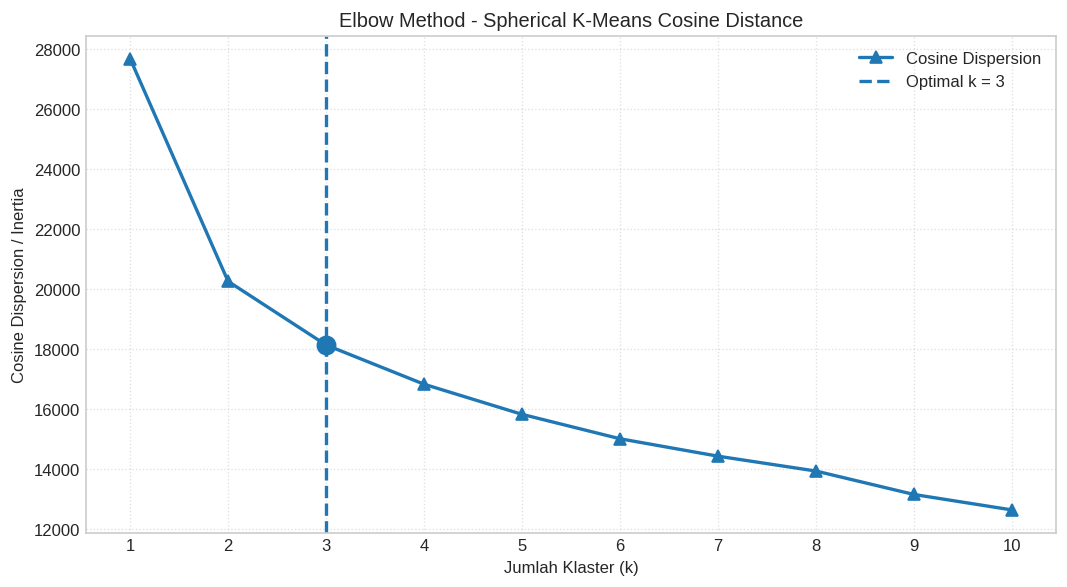

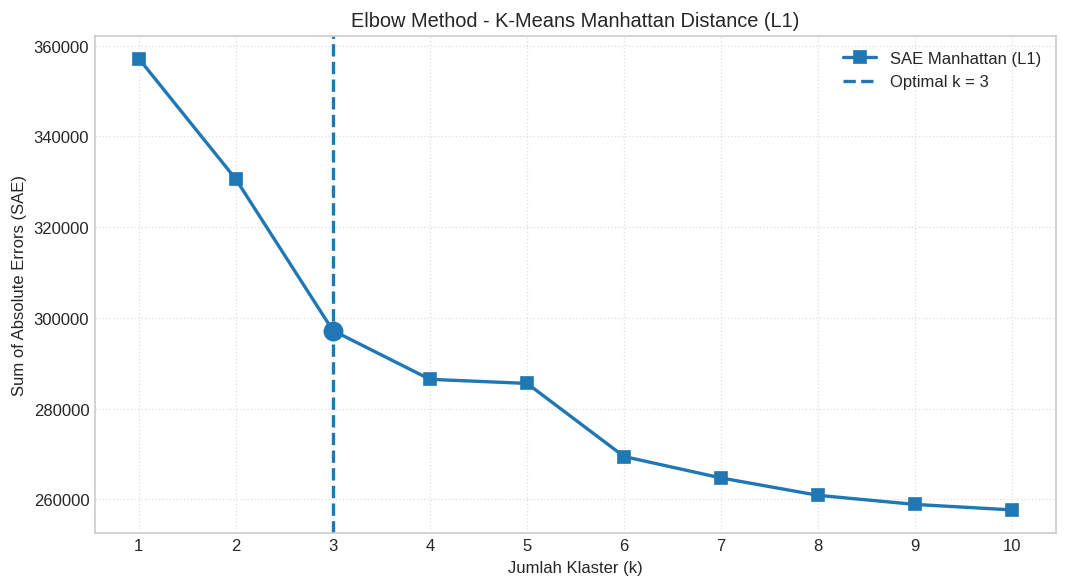

In [18]:
# =======================================================================
# 4. ELBOW METHOD COSINE & MANHATTAN (k = 1..10)
# =======================================================================
# Elbow dihitung menggunakan sampel agar 10 kali proses clustering tidak
# terlalu berat untuk dataset BRFSS yang sangat besar.
rng = np.random.RandomState(RANDOM_STATE)

if len(X_scaled) > ELBOW_SAMPLE_SIZE:
    elbow_idx = rng.choice(len(X_scaled), ELBOW_SAMPLE_SIZE, replace=False)
    X_elbow_man = X_scaled[elbow_idx]
    X_elbow_cos = X_norm[elbow_idx]
else:
    X_elbow_man = X_scaled
    X_elbow_cos = X_norm

print(f"[ELBOW] Data yang digunakan: {len(X_elbow_man):,} sampel")

k_range = list(range(1, 11))
sae_manhattan = []
inertia_cosine = []

for k in k_range:
    print(f"[ELBOW] Memproses k={k} ...")

    km_cos = KMeansCosine(n_clusters=k, max_iter=50, random_state=RANDOM_STATE)
    km_cos.fit(X_elbow_cos)
    inertia_cosine.append(km_cos.inertia_)

    km_man = KMeansManhattan(n_clusters=k, max_iter=50, random_state=RANDOM_STATE)
    km_man.fit(X_elbow_man)
    sae_manhattan.append(km_man.inertia_)

optimal_k_cosine = find_elbow_point(k_range, inertia_cosine)
optimal_k_manhattan = find_elbow_point(k_range, sae_manhattan)

print(f"\n[ELBOW COSINE] Optimal k = {optimal_k_cosine}")
print(f"[ELBOW MANHATTAN] Optimal k = {optimal_k_manhattan}")

# -------------------- Grafik Elbow Cosine --------------------
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_cosine, marker='^', markersize=7, linewidth=2, label='Cosine Dispersion')
plt.axvline(optimal_k_cosine, linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k_cosine}')
plt.scatter([optimal_k_cosine], [inertia_cosine[optimal_k_cosine - 1]], s=120, zorder=5)
plt.title('Elbow Method - Spherical K-Means Cosine Distance')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Cosine Dispersion / Inertia')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
elbow_cos_path = os.path.join(OUTPUT_DIR, 'elbow_cosine.png')
plt.savefig(elbow_cos_path, dpi=300)
plt.show()

# -------------------- Grafik Elbow Manhattan --------------------
plt.figure(figsize=(9, 5))
plt.plot(k_range, sae_manhattan, marker='s', markersize=7, linewidth=2, label='SAE Manhattan (L1)')
plt.axvline(optimal_k_manhattan, linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k_manhattan}')
plt.scatter([optimal_k_manhattan], [sae_manhattan[optimal_k_manhattan - 1]], s=120, zorder=5)
plt.title('Elbow Method - K-Means Manhattan Distance (L1)')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Sum of Absolute Errors (SAE)')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
elbow_man_path = os.path.join(OUTPUT_DIR, 'elbow_manhattan.png')
plt.savefig(elbow_man_path, dpi=300)
plt.show()

In [19]:
# =======================================================================
# 5. CLUSTERING FINAL, EVALUASI, & EKSPOR EXCEL
# =======================================================================
print("[FINAL] Menjalankan K-Means Cosine pada seluruh data...")
model_cosine = KMeansCosine(
    n_clusters=optimal_k_cosine,
    max_iter=100,
    tol=1e-4,
    random_state=RANDOM_STATE
)
model_cosine.fit(X_norm)

print("[FINAL] Menjalankan K-Means Manhattan pada seluruh data...")
model_manhattan = KMeansManhattan(
    n_clusters=optimal_k_manhattan,
    max_iter=100,
    tol=1e-4,
    random_state=RANDOM_STATE
)
model_manhattan.fit(X_scaled)

# Silhouette menggunakan sampel karena perhitungan full pairwise pada 200k+ data
# membutuhkan RAM sangat besar. Metric tetap sesuai masing-masing algoritma.
sil_n = min(SILHOUETTE_SAMPLE_SIZE, len(X_scaled))

sil_cos = float(silhouette_score(
    X_norm,
    model_cosine.labels_,
    metric='cosine',
    sample_size=sil_n,
    random_state=RANDOM_STATE
))

sil_man = float(silhouette_score(
    X_scaled,
    model_manhattan.labels_,
    metric='manhattan',
    sample_size=sil_n,
    random_state=RANDOM_STATE
))

# Davies-Bouldin dan Calinski-Harabasz dihitung pada seluruh data.
db_cos = float(davies_bouldin_score(X_norm, model_cosine.labels_))
ch_cos = float(calinski_harabasz_score(X_norm, model_cosine.labels_))

db_man = float(davies_bouldin_score(X_scaled, model_manhattan.labels_))
ch_man = float(calinski_harabasz_score(X_scaled, model_manhattan.labels_))

eval_df = pd.DataFrame([
    {
        'Distance Metric': 'Cosine Distance (Spherical)',
        'Optimal k': optimal_k_cosine,
        'Silhouette Score (sample)': round(sil_cos, 4),
        'Davies-Bouldin Index': round(db_cos, 4),
        'Calinski-Harabasz Index': round(ch_cos, 2),
        'Execution Time (s)': round(model_cosine.execution_time_, 5),
        'Iterations': model_cosine.n_iter_,
        'Objective Value (Inertia)': round(model_cosine.inertia_, 2)
    },
    {
        'Distance Metric': 'Manhattan Distance (L1)',
        'Optimal k': optimal_k_manhattan,
        'Silhouette Score (sample)': round(sil_man, 4),
        'Davies-Bouldin Index': round(db_man, 4),
        'Calinski-Harabasz Index': round(ch_man, 2),
        'Execution Time (s)': round(model_manhattan.execution_time_, 5),
        'Iterations': model_manhattan.n_iter_,
        'Objective Value (Inertia)': round(model_manhattan.inertia_, 2)
    }
])

print("\n" + "=" * 110)
print("TABEL EVALUASI K-MEANS COSINE & MANHATTAN")
print("=" * 110)
print(eval_df.to_string(index=False))
print("=" * 110)

# Data terklaster menggunakan df hasil preprocessing agar jumlah baris
# sama persis dengan jumlah label cluster.
df_clustered = df.copy()
df_clustered['Cluster_Cosine'] = model_cosine.labels_
df_clustered['Cluster_Manhattan'] = model_manhattan.labels_

excel_path = os.path.join(OUTPUT_DIR, 'evaluasi_kmeans_manhattan_cosine.xlsx')
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Excel: {excel_path}")
print(f"[INFO] Silhouette dihitung menggunakan sampel {sil_n:,} data, sedangkan DB dan CH menggunakan seluruh data.")

[FINAL] Menjalankan K-Means Cosine pada seluruh data...
[FINAL] Menjalankan K-Means Manhattan pada seluruh data...

TABEL EVALUASI K-MEANS COSINE & MANHATTAN
            Distance Metric  Optimal k  Silhouette Score (sample)  Davies-Bouldin Index  Calinski-Harabasz Index  Execution Time (s)  Iterations  Objective Value (Inertia)
Cosine Distance (Spherical)          3                     0.1527                3.0280                 17993.03             2.98950          29                  127409.29
    Manhattan Distance (L1)          3                     0.1391                3.1486                 12666.98             1.02139           4                 2113633.68
[SIMPAN] Excel: output_clustering/evaluasi_kmeans_manhattan_cosine.xlsx
[INFO] Silhouette dihitung menggunakan sampel 5,000 data, sedangkan DB dan CH menggunakan seluruh data.


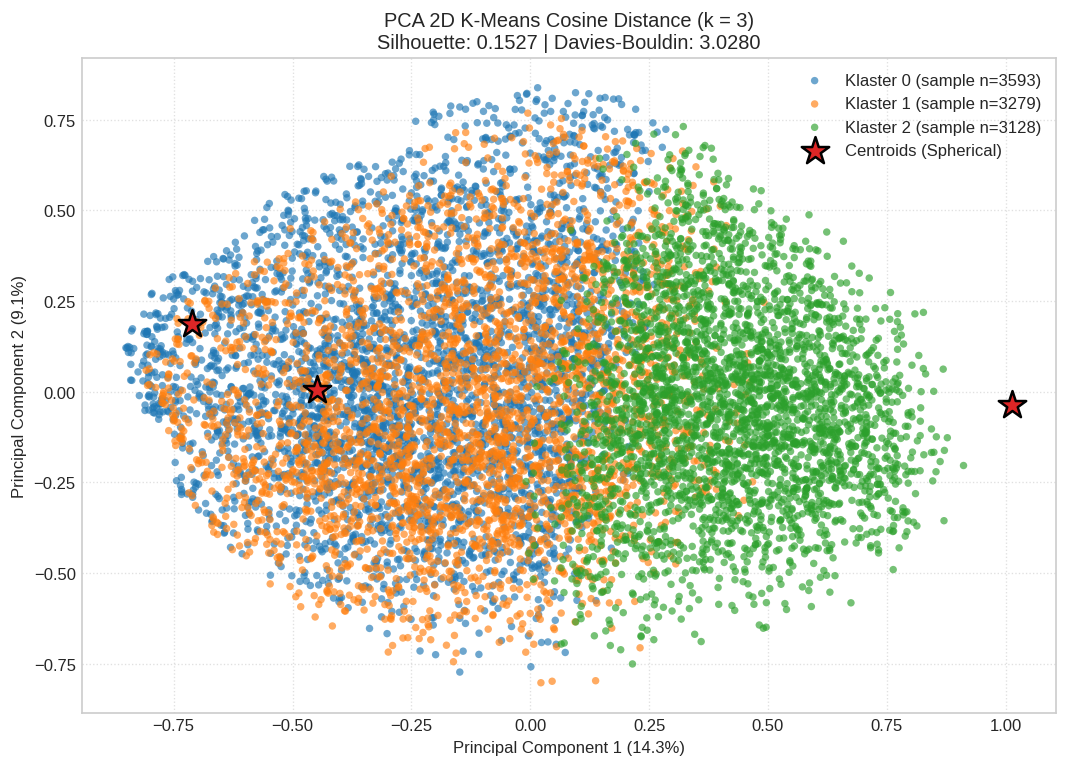

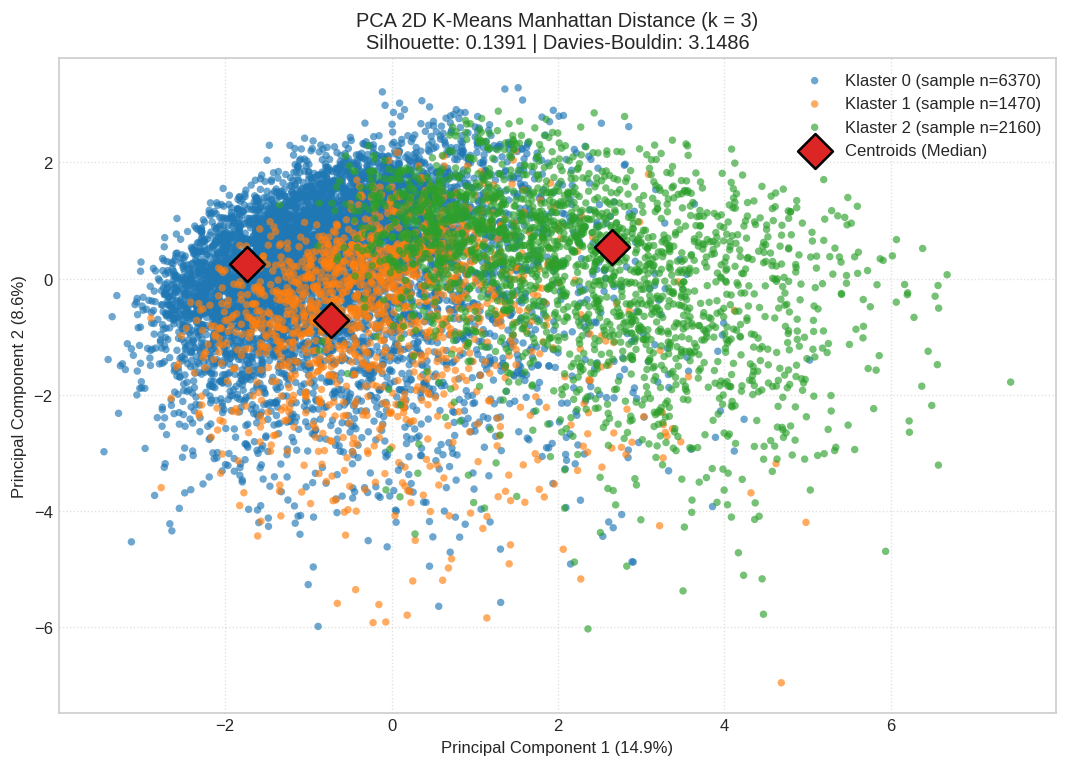

[SIMPAN] PCA Cosine    : output_clustering/cluster_cosine.png
[SIMPAN] PCA Manhattan : output_clustering/cluster_manhattan.png


In [20]:
# =======================================================================
# 6. VISUALISASI PCA 2D COSINE & MANHATTAN
# =======================================================================
# PCA dan scatter plot menggunakan sampel agar visualisasi tetap ringan.
rng = np.random.RandomState(RANDOM_STATE)
vis_n = min(PCA_SAMPLE_SIZE, len(X_scaled))
vis_idx = rng.choice(len(X_scaled), vis_n, replace=False)

# -------------------- PCA Cosine --------------------
pca_cos = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_cos = pca_cos.fit_transform(X_norm[vis_idx])
centroids_pca_cos = pca_cos.transform(model_cosine.centroids)

plt.figure(figsize=(9, 6.5))
palette_cos = sns.color_palette('tab10', optimal_k_cosine)

for k in range(optimal_k_cosine):
    mask = model_cosine.labels_[vis_idx] == k
    plt.scatter(
        X_pca_cos[mask, 0], X_pca_cos[mask, 1],
        color=palette_cos[k],
        label=f'Klaster {k} (sample n={np.sum(mask)})',
        alpha=0.65,
        s=20,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca_cos[:, 0], centroids_pca_cos[:, 1],
    marker='*', s=300, c='#DC2626', edgecolor='black', linewidth=1.5,
    label='Centroids (Spherical)', zorder=10
)
plt.title(
    f'PCA 2D K-Means Cosine Distance (k = {optimal_k_cosine})\n'
    f'Silhouette: {sil_cos:.4f} | Davies-Bouldin: {db_cos:.4f}'
)
plt.xlabel(f'Principal Component 1 ({pca_cos.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_cos.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')
plt.tight_layout()
cos_pca_path = os.path.join(OUTPUT_DIR, 'cluster_cosine.png')
plt.savefig(cos_pca_path, dpi=300)
plt.show()

# -------------------- PCA Manhattan --------------------
pca_man = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_man = pca_man.fit_transform(X_scaled[vis_idx])
centroids_pca_man = pca_man.transform(model_manhattan.centroids)

plt.figure(figsize=(9, 6.5))
palette_man = sns.color_palette('tab10', optimal_k_manhattan)

for k in range(optimal_k_manhattan):
    mask = model_manhattan.labels_[vis_idx] == k
    plt.scatter(
        X_pca_man[mask, 0], X_pca_man[mask, 1],
        color=palette_man[k],
        label=f'Klaster {k} (sample n={np.sum(mask)})',
        alpha=0.65,
        s=20,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca_man[:, 0], centroids_pca_man[:, 1],
    marker='D', s=220, c='#DC2626', edgecolor='black', linewidth=1.5,
    label='Centroids (Median)', zorder=10
)
plt.title(
    f'PCA 2D K-Means Manhattan Distance (k = {optimal_k_manhattan})\n'
    f'Silhouette: {sil_man:.4f} | Davies-Bouldin: {db_man:.4f}'
)
plt.xlabel(f'Principal Component 1 ({pca_man.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_man.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')
plt.tight_layout()
man_pca_path = os.path.join(OUTPUT_DIR, 'cluster_manhattan.png')
plt.savefig(man_pca_path, dpi=300)
plt.show()

print(f"[SIMPAN] PCA Cosine    : {cos_pca_path}")
print(f"[SIMPAN] PCA Manhattan : {man_pca_path}")